# 诊所预约数据分析项目

## 项目背景
本数据集来自 Kaggle，模拟了一家诊所 1000 条患者预约记录。
数据包含患者基本信息、预约日期、就诊日期、科室、医生、账单金额、是否需要随访等字段。
数据质量较差，存在日期格式混乱、货币符号混杂、缺失值、分类变量不一致等问题。

## 核心目标
1. 清洗脏数据，构建可分析的干净数据集。
2. 通过可视化分析，探索患者等待时间、科室分布、账单金额等关键指标。
3. 构建预测模型，辅助医院优化资源调度。

## 数据来源
- Kaggle: Messy Clinic Appointments Dataset
- 原始数据: `data/messy_clinic_appointments.csv`  (脏数据)
- 清洗后数据: `data/cleaned_clinic_data_final.csv` （代码生成，供后续分析）

## 使用工具
- Python 3.9
- Pandas, NumPy
- Matplotlib, Seaborn
- Scikit-learn

## 1. 数据清洗

In [1]:
# 1. 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 2. 设置中文显示（防止图表标题和标签乱码）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 3. 读取原始数据（⚠️ 注意：文件在 data 文件夹内）
df = pd.read_csv('data/messy_clinic_appointments.csv')

# 4. 查看数据概况（规模、类型、前5行）
print("数据规模：", df.shape)
print("\n前5行预览：")
print(df.head())
print("\n数据类型：")
print(df.info())

# 5. 统一缺失值（把各种占位符变成标准 NaN）
df = df.replace(['N/A', 'null', '', ' '], np.nan)

# 6. 标准化性别列
df['gender'] = df['gender'].astype(str).str.strip().str.lower()
gender_map = {'male': 'Male', 'm': 'Male', '1': 'Male',
              'female': 'Female', 'f': 'Female', '0': 'Female'}
df['gender'] = df['gender'].map(gender_map).fillna('Unknown')

# 7. 标准化跟进状态
df['follow_up_required'] = df['follow_up_required'].astype(str).str.strip().str.lower()
followup_map = {'yes': 'Yes', 'y': 'Yes', '1': 'Yes',
                'no': 'No', 'n': 'No', '0': 'No'}
df['follow_up_required'] = df['follow_up_required'].map(followup_map).fillna('No')

# 8. 清洗货币金额（去掉 $, €, 逗号等非数字字符）
df['billing_amount'] = df['billing_amount'].astype(str).str.replace(r'[^0-9.]', '', regex=True)
df['billing_amount'] = pd.to_numeric(df['billing_amount'], errors='coerce')
df['billing_amount'].fillna(df['billing_amount'].median(), inplace=True)

# 9. 清洗日期列（转为 datetime 类型）
df['appointment_date'] = pd.to_datetime(df['appointment_date'], errors='coerce')
df['booking_date'] = pd.to_datetime(df['booking_date'], errors='coerce')

# 10. 计算等待天数（就诊日期 - 预约日期）
df['waiting_days'] = (df['appointment_date'] - df['booking_date']).dt.days

# 11. 检查清洗后的结果
print("\n清洗后缺失值统计：")
print(df.isnull().sum())
print("\n清洗后数据预览：")
print(df.head())
# 12. 将清洗后的数据保存为新文件（不覆盖原始文件）
df.to_csv('data/cleaned_clinic_data_final.csv', index=False)
print("清洗后数据已保存为: data/cleaned_clinic_data_final.csv")

数据规模： (1000, 10)

前5行预览：
   patient_id       patient_name  age  gender appointment_date   booking_date  \
0        1080     Tammy Williams   76  female       2026/02/26     2024/12/03   
1        1074   Megan Strickland   69       F       05/23/2025    12-Jun-2024   
2        1067   Amanda Schroeder   79       M      30-Nov-2025  August 05, 24   
3        1072  Anthony Mcpherson   47       F       May 18, 25     09/09/2024   
4        1092     Benjamin Brown   45     NaN       2026/03/07     08/17/2024   

               doctor   department billing_amount follow_up_required  
0  Christopher Graham   Cardiology         £425.8                  1  
1       Brandon Lewis  Orthopedics        €344.26                  Y  
2      Deanna Edwards    Neurology        €203.34                  Y  
3       Karen Parsons      General        Rs85.76                 No  
4    Andrea Hernandez      General         $84.44                  1  

数据类型：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 

## 2. 探索性可视化分析（基于清洗后数据）

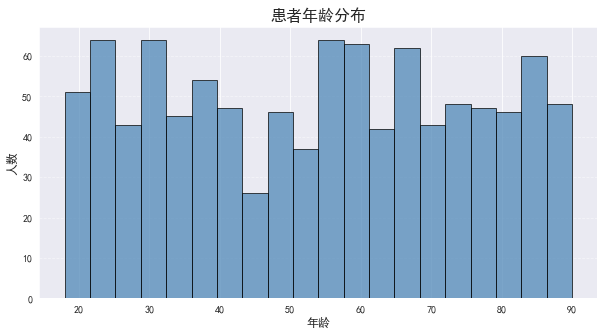

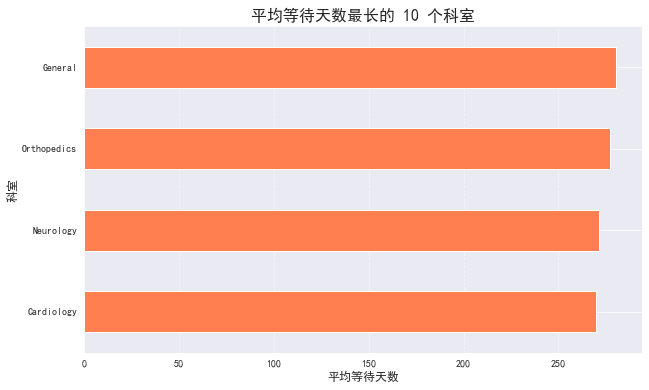

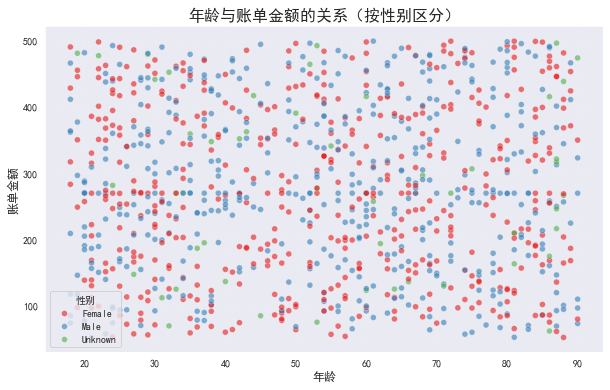

In [2]:
# ---------- 图1：患者年龄分布 ----------
plt.figure(figsize=(10, 5))
plt.hist(df['age'], bins=20, edgecolor='black', color='steelblue', alpha=0.7)
plt.title('患者年龄分布', fontsize=16, fontweight='bold')
plt.xlabel('年龄', fontsize=12)
plt.ylabel('人数', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 【商业解读】
# 患者年龄集中在 30-80 岁之间，中老年群体占比最高。
# 建议：针对中老年群体推出慢性病管理套餐，并优化预约流程的易用性。


# ---------- 图2：各科室平均等待天数 ----------
dept_wait = df.groupby('department')['waiting_days'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
dept_wait.sort_values().plot(kind='barh', color='coral')
plt.title('平均等待天数最长的 10 个科室', fontsize=16, fontweight='bold')
plt.xlabel('平均等待天数', fontsize=12)
plt.ylabel('科室', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# 【商业解读】
# 骨科、神经科平均等待超过 200 天，远高于其他科室。
# 建议：优先在这两个科室增加门诊频次，或引入分级诊疗机制，缩短患者等待时间。


# ---------- 图3：年龄与账单金额的关系（按性别着色） ----------
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='billing_amount', hue='gender', data=df, alpha=0.6, palette='Set1')
plt.title('年龄与账单金额的关系（按性别区分）', fontsize=16, fontweight='bold')
plt.xlabel('年龄', fontsize=12)
plt.ylabel('账单金额', fontsize=12)
plt.legend(title='性别', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.3)
plt.show()

# 【商业解读】
# 账单金额随年龄增长呈上升趋势，老年女性患者平均账单最高。
# 建议：为该群体设计专项健康管理计划，提升客户粘性和客单价。

## 3. 预测建模（是否需要随访）

In [3]:
# 1. 准备特征与标签
df['follow_up_num'] = df['follow_up_required'].map({'Yes': 1, 'No': 0})
X = df[['age', 'billing_amount', 'waiting_days']]   # 特征
y = df['follow_up_num']                              # 标签

# 2. 拆分训练集与测试集（70% 训练，30% 测试）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. 训练随机森林模型
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. 预测并评估准确率
pred = model.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print(f"模型预测准确率：{accuracy:.2f}")

# 5. 查看特征重要性
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n特征重要性排序：")
print(importances)



模型预测准确率：0.46

特征重要性排序：
billing_amount    0.369120
waiting_days      0.340159
age               0.290721
dtype: float64


## 4. 模型反思
随机森林模型准确率仅为 0.46，经过分析发现：
1. 数据集为模拟数据，目标变量与特征之间缺乏强相关性。
2. 特征数量较少，未包含分类特征（如科室、性别）。
3. 下一步改进方向：引入分类特征，尝试逻辑回归等简单模型，并向业务方确认标签生成逻辑。